In [58]:
# Fill in your information
name = "Md. Ammar Hamim"           # Write your full name here
email = "ammarhamim7@gmail.com"          # Write your registered email here

print(f"Name  : {name}")
print(f"Email : {email}")

Name  : Md. Ammar Hamim
Email : ammarhamim7@gmail.com


In [59]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [60]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import TargetEncoder

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import MaxAbsScaler

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegressionCV
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [61]:
df=pd.read_csv("/content/adult_income.csv")

df.sample(5)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
19686,27,Self-emp-not-inc,207948,Some-college,10,Never-married,Other-service,Not-in-family,Black,Male,0,0,40,United-States,<=50K
28175,19,?,39460,HS-grad,9,Never-married,?,Own-child,White,Male,0,0,60,United-States,<=50K
18001,36,Private,178815,Bachelors,13,Never-married,Exec-managerial,Not-in-family,White,Male,8614,0,40,United-States,>50K
19103,23,Private,253190,Assoc-acdm,12,Married-civ-spouse,Handlers-cleaners,Husband,White,Male,0,0,25,United-States,<=50K
32253,42,Self-emp-not-inc,34037,Bachelors,13,Never-married,Farming-fishing,Own-child,White,Male,0,0,35,United-States,<=50K


# Question 1

In [62]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [63]:
display(df.duplicated().sum())
df.drop_duplicates(inplace=True)
display(df.duplicated().sum())

np.int64(29)

np.int64(0)

In [64]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48813.000000,4.881300e+04,48813.000000,48813.000000,48813.000000,48813.000000
mean,38.647348,1.896679e+05,10.078688,1079.708705,87.554299,40.425051
std,13.709005,1.056062e+05,2.570257,7454.185982,403.118605,12.390954
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175550e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781400e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376200e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48813 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48813 non-null  int64 
 1   workclass       48813 non-null  object
 2   fnlwgt          48813 non-null  int64 
 3   education       48813 non-null  object
 4   education-num   48813 non-null  int64 
 5   marital-status  48813 non-null  object
 6   occupation      48813 non-null  object
 7   relationship    48813 non-null  object
 8   race            48813 non-null  object
 9   sex             48813 non-null  object
 10  capital-gain    48813 non-null  int64 
 11  capital-loss    48813 non-null  int64 
 12  hours-per-week  48813 non-null  int64 
 13  native-country  48813 non-null  object
 14  income          48813 non-null  object
dtypes: int64(6), object(9)
memory usage: 6.0+ MB


In [66]:
df['income']

,income
0,<=50K
1,<=50K
2,<=50K
3,<=50K
4,<=50K
...,...
48837,<=50K.
48838,<=50K.
48839,<=50K.
48840,<=50K.


In [67]:
df.income = df.income.str.strip(". ")

In [68]:
df['income'].value_counts()

,count
income,
<=50K,37128
>50K,11685


In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48813 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48813 non-null  int64 
 1   workclass       48813 non-null  object
 2   fnlwgt          48813 non-null  int64 
 3   education       48813 non-null  object
 4   education-num   48813 non-null  int64 
 5   marital-status  48813 non-null  object
 6   occupation      48813 non-null  object
 7   relationship    48813 non-null  object
 8   race            48813 non-null  object
 9   sex             48813 non-null  object
 10  capital-gain    48813 non-null  int64 
 11  capital-loss    48813 non-null  int64 
 12  hours-per-week  48813 non-null  int64 
 13  native-country  48813 non-null  object
 14  income          48813 non-null  object
dtypes: int64(6), object(9)
memory usage: 6.0+ MB


In [70]:
numerical_columns = df.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
categorical_columns.remove('income')
print(numerical_columns)
print(categorical_columns)

['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


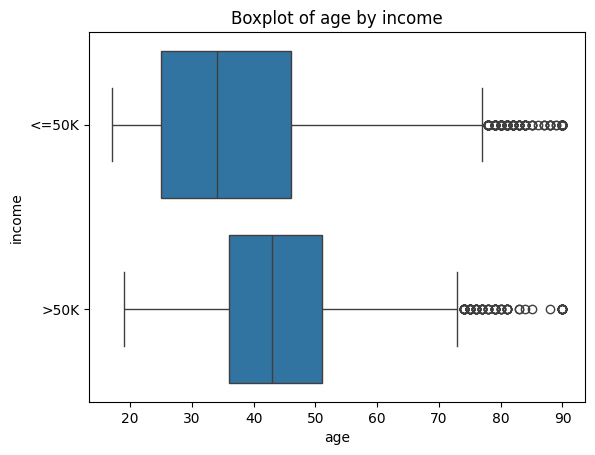

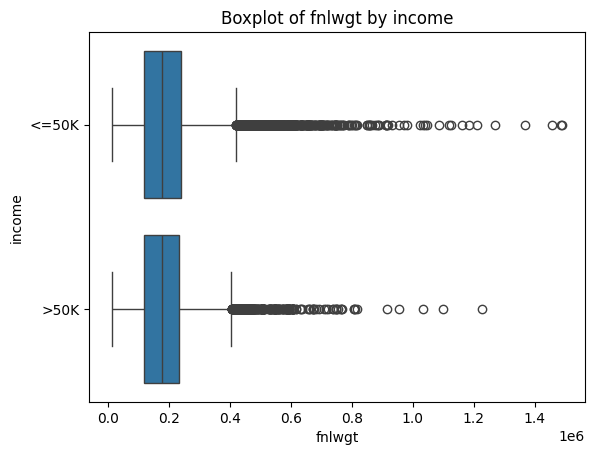

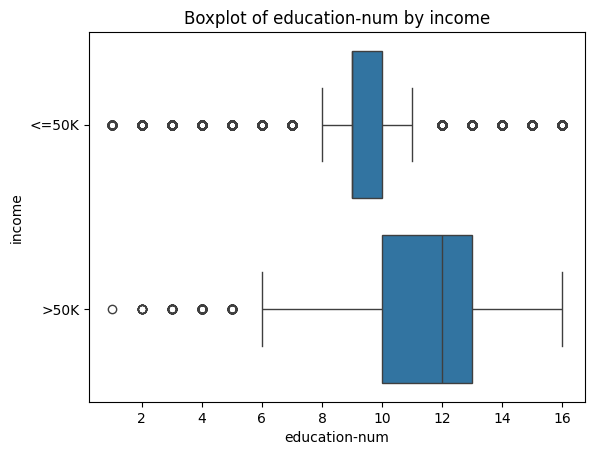

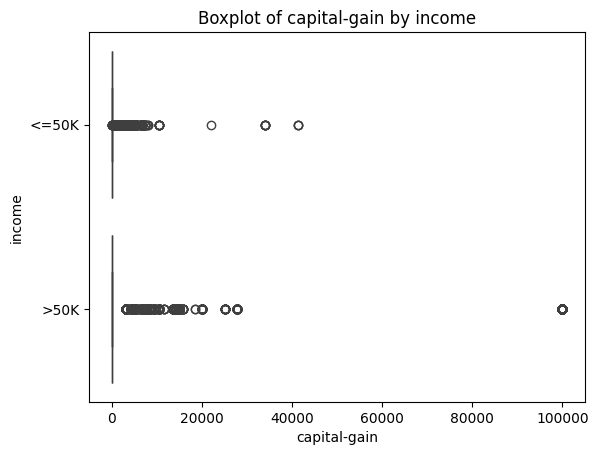

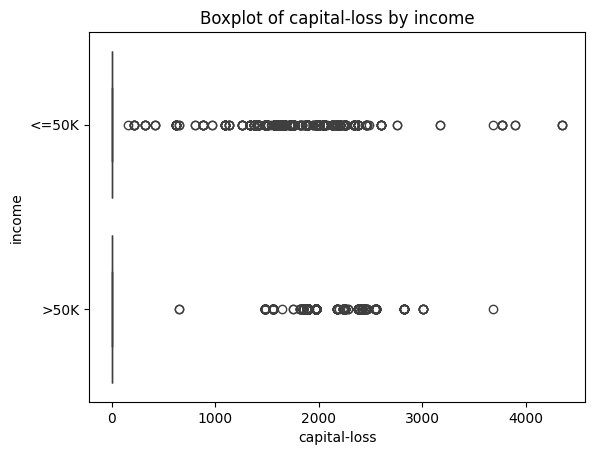

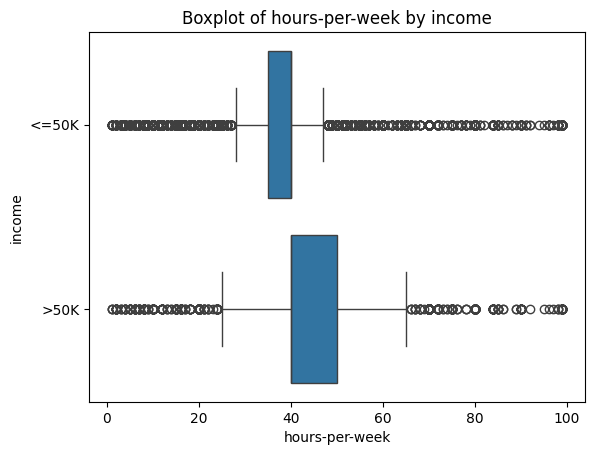

In [71]:
for col in numerical_columns:
  sns.boxplot(data = df, x = col, y = 'income')
  plt.title(f"Boxplot of {col} by income")
  plt.show()

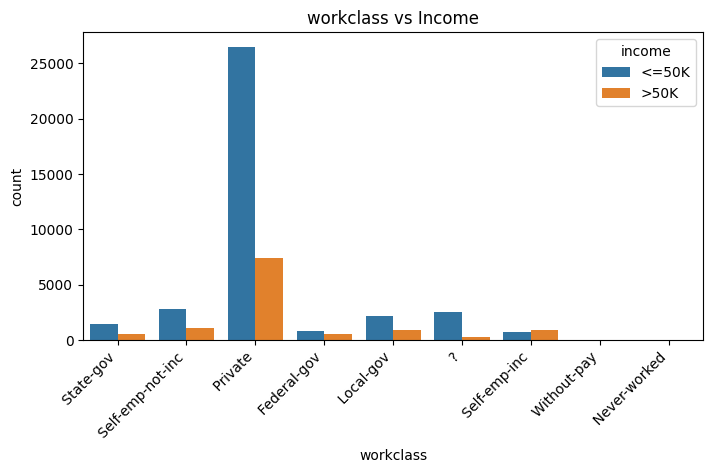

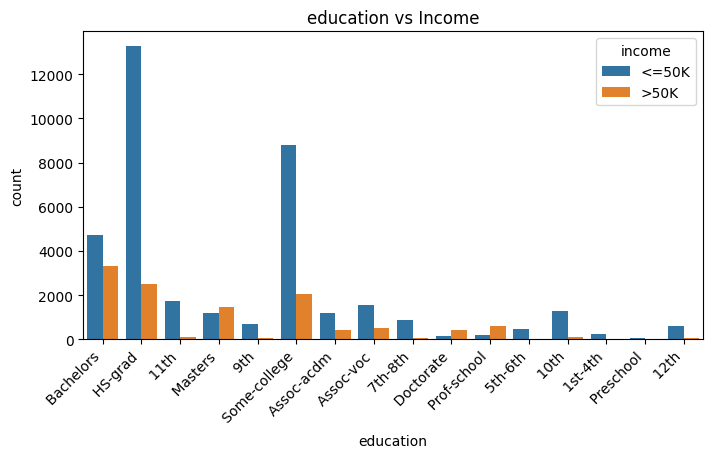

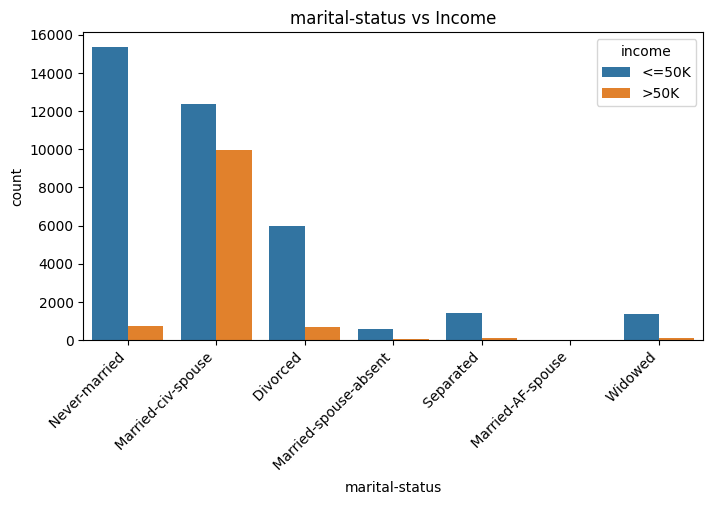

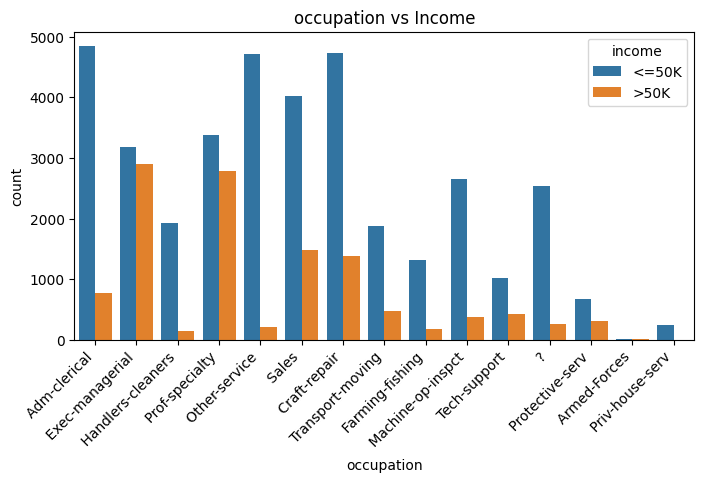

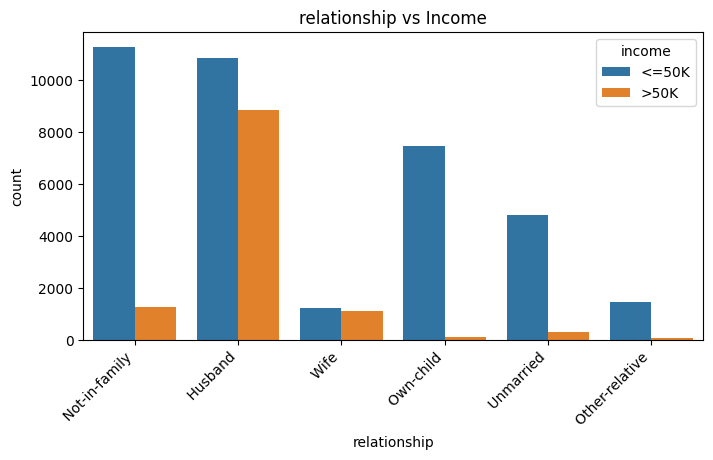

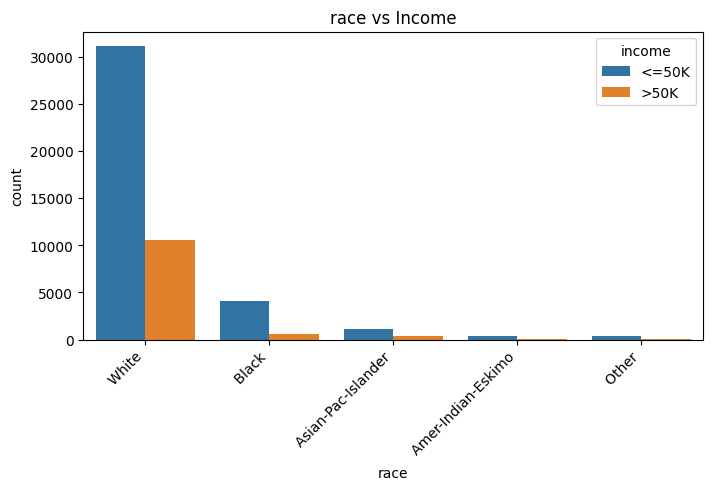

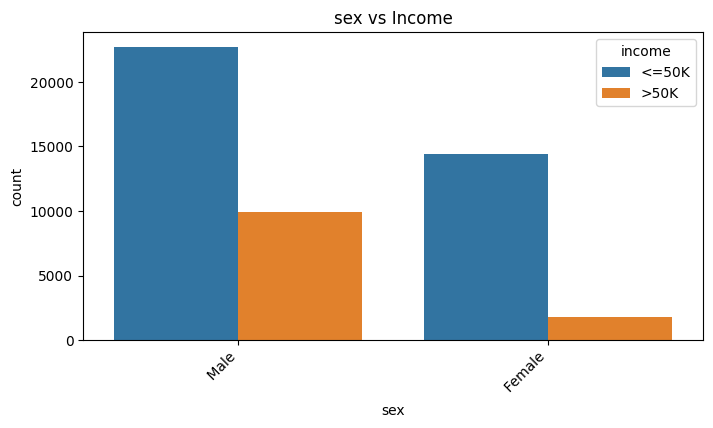

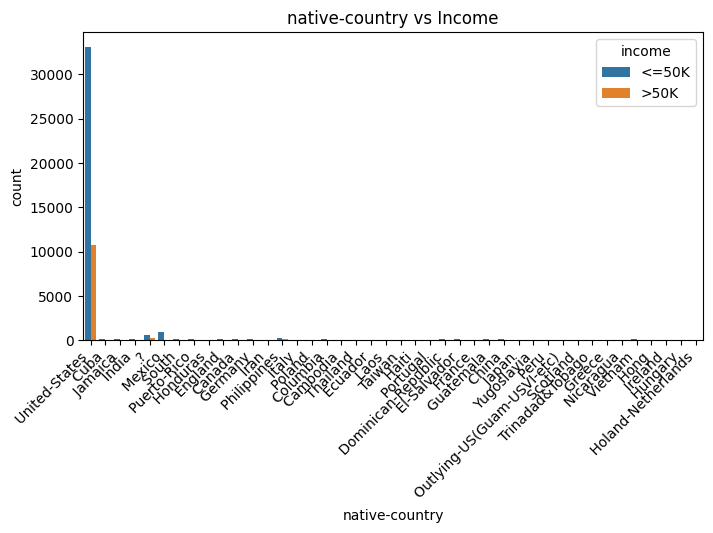

In [72]:
for col in categorical_columns:
    plt.figure(figsize=(8,4))
    sns.countplot(x=col, hue='income', data=df)
    plt.xticks(rotation=45, ha='right')
    plt.title(f'{col} vs Income')
    plt.show()

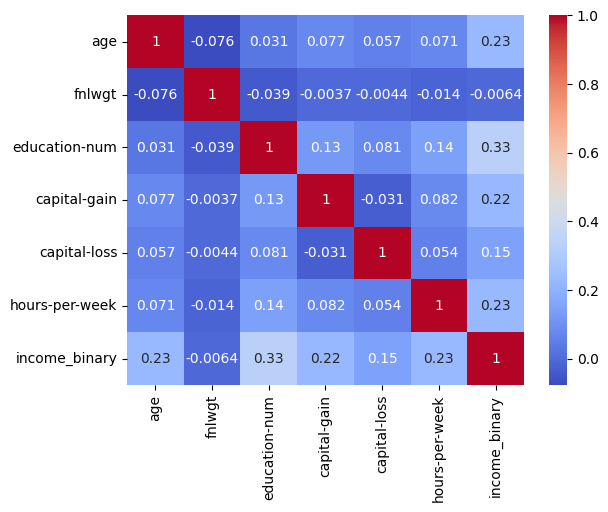

In [73]:
df['income_binary'] = df['income'].map({'<=50K': 0, '>50K': 1})


corrmap = df[numerical_columns + ['income_binary']].corr()
sns.heatmap(corrmap, annot=True, cmap='coolwarm')
plt.show()

In [74]:
for col in categorical_columns:
    print(f"{col}")
    percent = df.groupby(col)['income'].value_counts(normalize=True) * 100
    print(percent.round(2))
    print()

workclass
workclass         income
?                 <=50K      90.53
                  >50K        9.47
Federal-gov       <=50K      60.82
                  >50K       39.18
Local-gov         <=50K      70.44
                  >50K       29.56
Never-worked      <=50K     100.00
Private           <=50K      78.20
                  >50K       21.80
Self-emp-inc      >50K       55.37
                  <=50K      44.63
Self-emp-not-inc  <=50K      72.11
                  >50K       27.89
State-gov         <=50K      73.25
                  >50K       26.75
Without-pay       <=50K      90.48
                  >50K        9.52
Name: proportion, dtype: float64

education
education     income
10th          <=50K     93.74
              >50K       6.26
11th          <=50K     94.92
              >50K       5.08
12th          <=50K     92.68
              >50K       7.32
1st-4th       <=50K     96.73
              >50K       3.27
5th-6th       <=50K     94.69
              >50K       5.31
7th-8

### Three Most Important Features Affecting Income

1. Education
2. Marital Status
3. Occupation

i. Education

In education who has a doctorate, the chance to earn more than 50k is almost 73%, on the other hand those with pre school education have about a 1% chance. This creates a gap of nearly 72 percentage points, indicating a strong relationship between education level and income.

ii. Marital Status

Marital status is another significant factor. People who are Married-civ-spouse have approximately a 45% chance of earning more than $50K, while those who have Never-married status have only about a 4.5% chance. The large difference between these groups highlights the impact of marital status on income levels.

iii. Occupation

those working in Exec-managerial positions have a 47.78% chance of earning more than $50K, whereas those employed in Priv-house-serv occupations have only a 1.24% chance. This difference is 46 points.


# why the selected features affect the income

Education: If someone studies more, they usually get better skills, so they get better jobs and more salary. That's why education matters a lot for income.

Marital Status: Married people are mostly a bit older and already settled in their job/career. So naturally they earn more than people who are not married yet.

Occupation: Some jobs just pay more than others. Like a manager will obviously earn more than a house servant. So job type directly decides how much someone earns.

## Feature Ranking

1. Education
2. Marital Status
3. Occupation

I ranked Education first because it has the largest gap (about 71%) between people earning more than $50K and those earning less. Higher education often leads to better jobs and higher income.

Marital Status is second because it reflects factors such as age and life stability, which also have a strong impact on income.

Occupation is third because, although it shows a large income gap, it is often influenced by education. Better education usually leads to better occupations, making it less independent than the other two factors.


# Question 2

In [75]:
df.sex.value_counts()

,count
sex,
Male,32631
Female,16182


In [76]:
df.relationship.value_counts()

,count
relationship,
Husband,19709
Not-in-family,12567
Own-child,7576
Unmarried,5124
Wife,2331
Other-relative,1506


In [77]:
df.drop(columns=['education','fnlwgt','income'],inplace=True)
df.head()

,age,workclass,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income_binary
0,39,State-gov,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,0
1,50,Self-emp-not-inc,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,0
2,38,Private,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,0
3,53,Private,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,0
4,28,Private,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,0


In [78]:
X = df.drop(columns=['hours-per-week'])
y = df['hours-per-week']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [79]:
numeric_cols = ['age', 'education-num', 'capital-gain', 'capital-loss']
nominal_cols = ['workclass', 'marital-status', 'occupation', 'relationship',
                'race', 'sex', 'native-country']
binary_cols = ['income_binary']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

nominal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

binary_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

In [80]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('nom', nominal_transformer, nominal_cols),
        ('bin', binary_transformer, binary_cols)
])

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'education-num', 'capital-gain',
                                  'capital-loss']),
                                ('nom',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['workclass', 'marital-status', 'occupation',
                                  'relationship', 'race', 'sex',
                                  'native-country']),
                                ('bin',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent'))]),
                                 ['income_binary'])])

In [81]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

### Preprocessing

In the preprocessing stage, I treated age, education-num, capital-gain, and capital-loss as numerical features. Since education-num is already represented as an ordinal numerical value, I did not apply ordinal encoding and used scaling directly.

For the nominal categorical features, I first handled missing values using the most frequent value and then applied One-Hot Encoding.

The income column is already in binary format, so no encoding was required. I only handled any missing values using an imputation method.


# Question 3

In [82]:
lr_model = Pipeline(steps=[('preprocessor', preprocessor),
                           ('regressor', LinearRegression())])

sgd_model = Pipeline(steps=[('preprocessor', preprocessor),
                            ('regressor', SGDRegressor(max_iter=5000))])

lr_model.fit(X_train, y_train)
sgd_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
y_pred_sgd = sgd_model.predict(X_test)

r2_lr = r2_score(y_test, y_pred_lr)
r2_sgd = r2_score(y_test, y_pred_sgd)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
mae_sgd = mean_absolute_error(y_test, y_pred_sgd)

mse_lr = mean_squared_error(y_test, y_pred_lr)
mse_sgd = mean_squared_error(y_test, y_pred_sgd)

print("Linear Regression:")
print("R2 Score:", r2_lr)
print("MAE:", mae_lr)
print("MSE:", mse_lr)

print("\nSGD Regressor:")
print("R2 Score:", r2_sgd)
print("MAE:", mae_sgd)
print("MSE:", mse_sgd)



Linear Regression:
R2 Score: 0.1843231326780378
MAE: 7.754540866672531
MSE: 124.57619767591461

SGD Regressor:
R2 Score: 0.1841297264682057
MAE: 7.755208113510199
MSE: 124.60573610123113


### Model Comparison

The Linear Regression model performed slightly better than the SGD Regressor. It achieved better results in terms of R² Score,MAE and MSE though the differences were small.

However, both models performed poorly overall. This is because the dataset was primarily designed for predicting the income column and most features are more strongly related to income than to hours-per-week.

As a result, the hours-per-week feature has only a weak relationship with the other variables making it difficult for both models to predict it accurately.


# Question 4

In [83]:
X = df.drop(columns=['income_binary'])
y = df['income_binary']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify = y)

In [84]:
numeric_cols = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
nominal_cols = ['workclass', 'marital-status', 'occupation', 'relationship',
                'race', 'sex', 'native-country']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

nominal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [85]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('nom', nominal_transformer, nominal_cols)
])

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'education-num', 'capital-gain',
                                  'capital-loss', 'hours-per-week']),
                                ('nom',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['workclass', 'marital-status', 'occupation',
                                  'relationship', 'race', 'sex',
                                  'native-country'])])

In [88]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [89]:
lc_model = Pipeline(steps=[('preprocessor', preprocessor),
                           ('classifier', LogisticRegression())])

lc_model.fit(X_train, y_train)

y_pred_lc = lc_model.predict(X_test)

In [90]:
accuracy_lc = accuracy_score(y_test, y_pred_lc)
precision_lc = precision_score(y_test, y_pred_lc)
recall_lc = recall_score(y_test, y_pred_lc)

print("Logistic Regression:")
print("Accuracy:", accuracy_lc)
print("Precision:", precision_lc)
print("Recall:", recall_lc)

print(classification_report(y_test, y_pred_lc))

Logistic Regression:
Accuracy: 0.8555771791457544
Precision: 0.7425431711145997
Recall: 0.6071887034659821
              precision    recall  f1-score   support

           0       0.88      0.93      0.91      7426
           1       0.74      0.61      0.67      2337

    accuracy                           0.86      9763
   macro avg       0.81      0.77      0.79      9763
weighted avg       0.85      0.86      0.85      9763



# Question 5

In [91]:
knn_model = Pipeline(steps=[('preprocessor', preprocessor),
                           ('classifier', KNeighborsClassifier())])

param_grid = {
    'classifier__n_neighbors': [3, 5, 7, 9],
    'classifier__weights': ['uniform', 'distance'],
    'classifier__metric': ['euclidean', 'manhattan']
}

grid_search = GridSearchCV(
    estimator=knn_model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
grid_search.best_estimator_

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'education-num',
                                                   'capital-gain',
                                                   'capital-loss',
                                                   'hours-per-week']),
                                                 ('nom',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['workclass',
                                                   'marital-status',
                                                   'occupation', 'relationship',
                                                   'race', 'sex',
                                                   'native-country'])])),
                ('classifier',
                 KNeighborsClassifier(metric='euclidean', n_neighbors=9))])

In [93]:
best_pipeline = grid_search.best_estimator_
y_pred = best_pipeline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Tuned KNN Classifier Model:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print(classification_report(y_test, y_pred))

Tuned KNN Classifier Model:
Accuracy: 0.8470756939465328
Precision: 0.7040618955512572
Recall: 0.6230209670517758
              precision    recall  f1-score   support

           0       0.89      0.92      0.90      7426
           1       0.70      0.62      0.66      2337

    accuracy                           0.85      9763
   macro avg       0.79      0.77      0.78      9763
weighted avg       0.84      0.85      0.84      9763



## Model Comparison (Logistic Regression vs KNN)

The Logistic Regression model achieved an accuracy of 85.55%, while KNN achieved 84.70%, making Logistic Regression slightly better overall.

Logistic Regression also shows a marginally higher precision compared to KNN. In both models, precision is higher for the ≤50K income class, which is expected because the dataset is imbalanced and contains more samples in this class.

A similar pattern is observed in recall where both models perform better for the majority class (≤50K) but struggle with the >50K class.

In terms of F1-score, Logistic Regression again performs slightly better than KNN, although the difference is very small.

Overall, Logistic Regression is the better model, but both models show a clear bias toward predicting the ≤50K income class due to class imbalance in the dataset.
